In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
df = pd.read_csv("db/benchmark_results/eval/metrics_history.csv", sep=";")
df.head()

,id_turno,id_sessao,modelo,juiz,modo_rag,arquivo_origem,turno,style_rev,event_caus,adherence,time_order
0,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,1,1.000,0.917,1.0,1.0
1,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,2,0.875,0.875,1.0,1.0
2,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,3,1.000,0.917,1.0,1.0
3,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,4,1.000,0.917,1.0,1.0
4,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,5,0.875,0.833,1.0,1.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_turno        90 non-null     str    
 1   id_sessao       90 non-null     str    
 2   modelo          90 non-null     str    
 3   juiz            90 non-null     str    
 4   modo_rag        90 non-null     str    
 5   arquivo_origem  90 non-null     str    
 6   turno           90 non-null     int64  
 7   style_rev       90 non-null     float64
 8   event_caus      90 non-null     float64
 9   adherence       90 non-null     float64
 10  time_order      90 non-null     float64
dtypes: float64(4), int64(1), str(6)
memory usage: 28.8 KB


In [26]:
metricas = ['style_rev', 'event_caus', 'adherence', 'time_order']

## Agrupamento por arquitetura (RAG ou nao)

In [27]:
resumo_modo = df.groupby('modo_rag')[metricas].mean().reset_index()
print("Médias Gerais por Abordagem:")
print(resumo_modo)

Médias Gerais por Abordagem:
             modo_rag  style_rev  event_caus  adherence  time_order
0  Baseline (Sem RAG)   0.822222    0.859356   0.780556    0.933333
1          RAG Ligado   0.844444    0.851356   0.866667    0.927778


C:\Users\Aragão\AppData\Local\Temp\ipykernel_9148\3193755519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')


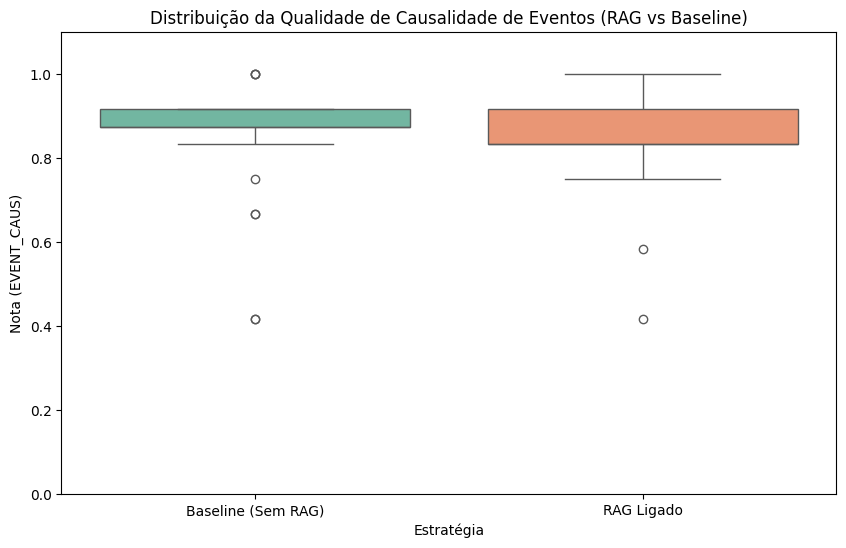

In [28]:
plt.figure(figsize=(10, 6))
# Exemplo focado na Causalidade de Eventos
sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')

plt.title('Distribuição da Qualidade de Causalidade de Eventos (RAG vs Baseline)')
plt.ylabel('Nota (EVENT_CAUS)')
plt.xlabel('Estratégia')
plt.ylim(0, 1.1) # Padroniza o eixo Y de 0 a 1 (com um respiro)
plt.show()

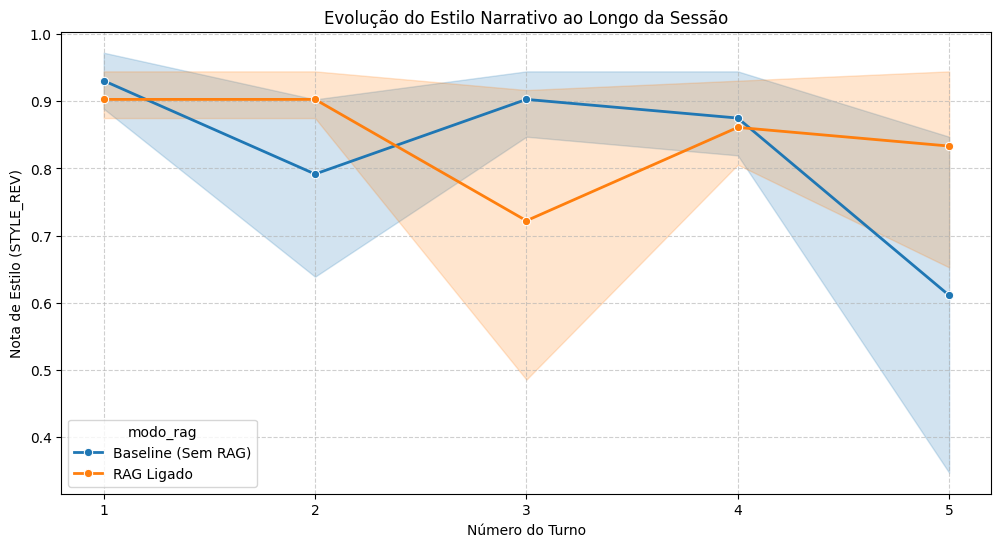

In [29]:
plt.figure(figsize=(12, 6))
# O Seaborn automaticamente calcula a média por turno e desenha uma margem de erro (intervalo de confiança)
sns.lineplot(data=df, x='turno', y='style_rev', hue='modo_rag', marker='o', linewidth=2)

plt.title('Evolução do Estilo Narrativo ao Longo da Sessão')
plt.ylabel('Nota de Estilo (STYLE_REV)')
plt.xlabel('Número do Turno')
plt.xticks(range(1, df['turno'].max() + 1)) # Garante que os números no eixo X sejam inteiros
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Agrupamento por modelo que Mestrou

In [30]:
df_agg_modelo = df.groupby(['modelo', 'modo_rag','juiz'])[metricas].mean().reset_index()

print("Média de Desempenho por Modelo:")
print(df_agg_modelo)

Média de Desempenho por Modelo:
                                      modelo            modo_rag    juiz  \
0             gemini-2.5-flash_baseline_rep1  Baseline (Sem RAG)  google   
1             gemini-2.5-flash_baseline_rep1  Baseline (Sem RAG)    groq   
2                  gemini-2.5-flash_rag_rep1          RAG Ligado  google   
3                  gemini-2.5-flash_rag_rep1          RAG Ligado    groq   
4           openai_gpt-4o-mini_baseline_rep1  Baseline (Sem RAG)  google   
5           openai_gpt-4o-mini_baseline_rep1  Baseline (Sem RAG)    groq   
6                openai_gpt-4o-mini_rag_rep1          RAG Ligado  google   
7                openai_gpt-4o-mini_rag_rep1          RAG Ligado    groq   
8   qwen_qwen-2.5-72b-instruct_baseline_rep1  Baseline (Sem RAG)  google   
9   qwen_qwen-2.5-72b-instruct_baseline_rep1  Baseline (Sem RAG)    groq   
10       qwen_qwen-2.5-72b-instruct_rag_rep1          RAG Ligado  google   
11       qwen_qwen-2.5-72b-instruct_rag_rep1          RA

In [31]:
df_melted = df_agg_modelo.melt(id_vars=['modelo','juiz'], value_vars=metricas, var_name='Metrica', value_name='Nota')
df_melted.head()

,modelo,juiz,Metrica,Nota
0,gemini-2.5-flash_baseline_rep1,google,style_rev,1.0000
1,gemini-2.5-flash_baseline_rep1,groq,style_rev,0.8250
2,gemini-2.5-flash_rag_rep1,google,style_rev,1.0000
3,gemini-2.5-flash_rag_rep1,groq,style_rev,0.8375
4,openai_gpt-4o-mini_baseline_rep1,google,style_rev,0.9250


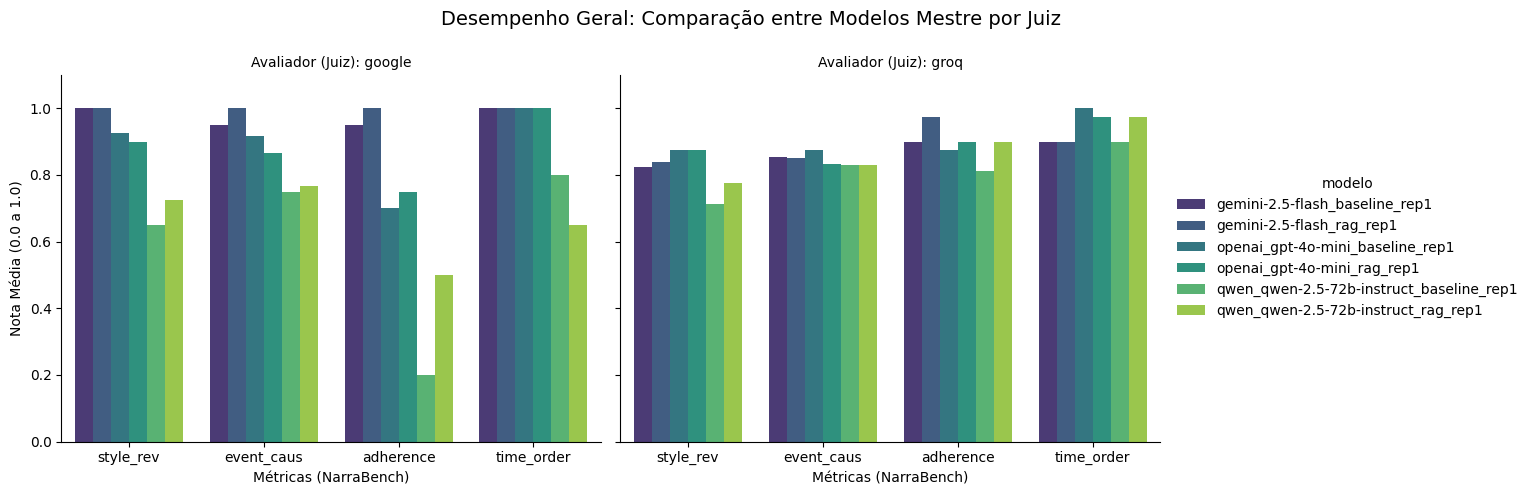

In [32]:
# O seu melt está certinho!
df_melted = df_agg_modelo.melt(id_vars=['modelo','juiz'], value_vars=metricas, var_name='Metrica', value_name='Nota')

# Usamos catplot passando col='juiz' para ele criar as subdivisões
g = sns.catplot(
    data=df_melted, 
    kind='bar',
    x='Metrica', 
    y='Nota', 
    hue='modelo', 
    col='juiz',        # <-- O SEGREDO ESTÁ AQUI (um gráfico para cada juiz)
    errorbar=None, 
    palette='viridis',
    height=5,          # Altura de cada gráfico
    aspect=1.2         # Largura de cada gráfico
)

# Ajustando os textos e eixos para ficar com cara de TCC
g.set_axis_labels("Métricas (NarraBench)", "Nota Média (0.0 a 1.0)")
g.set_titles("Avaliador (Juiz): {col_name}") # {col_name} vai ser substituído por 'groq' ou 'google'
g.set(ylim=(0, 1.1))

# Título global da figura
plt.subplots_adjust(top=0.85) # Dá um espacinho no topo
g.fig.suptitle('Desempenho Geral: Comparação entre Modelos Mestre por Juiz', fontsize=14)

plt.show()

C:\Users\Aragão\AppData\Local\Temp\ipykernel_9148\4161951064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='modelo', y='adherence', palette='Set3')


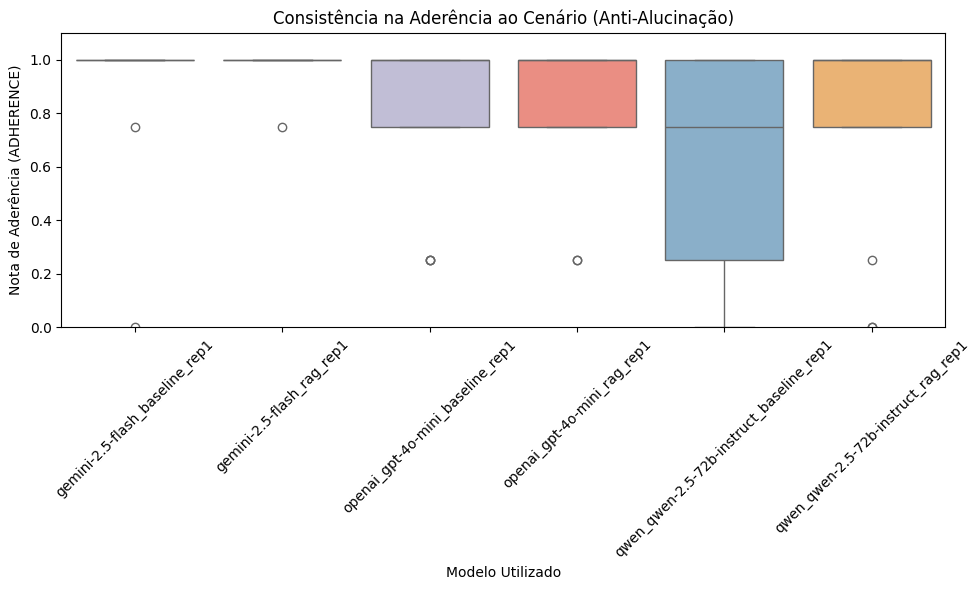

In [33]:
plt.figure(figsize=(10, 6))

# Exemplo focado na Fidelidade ao Lore (Adherence)
sns.boxplot(data=df, x='modelo', y='adherence', palette='Set3')

plt.title('Consistência na Aderência ao Cenário (Anti-Alucinação)')
plt.ylabel('Nota de Aderência (ADHERENCE)')
plt.xlabel('Modelo Utilizado')
plt.ylim(0, 1.1)

# Se os nomes dos modelos forem grandes (ex: "gemini-1.5-pro"), isto inclina o texto para não encavalar
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()